# A speed loop, closed around the model

`coaxial.loop`: blocks on one signal bus, `>>` chaining them into the
whole loop -- reference, probe, speed PI, current PI, machine. The machine
is `coaxial.motor.Motor`; every constant is an estimate
(`measured=False`), and the point of the run is `identify` putting the
constants back OUT of it, uncertainties attached, the same least squares
that will meet the real motor (`coaxial.sysid`).

The run: the 5230SL turning the APC20x10E from rest to full and back,
a 5 A d-axis probe riding along -- torque-free, and the only reason the
fit can see Ld at all.

In [1]:
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

root = Path.cwd()
while not (root / 'host' / 'coaxial').is_dir():
    root = root.parent
sys.path.insert(0, str(root / 'host'))

from coaxial.loop import (CurrentLoop, Machine, Probe, Ramp, SpeedLoop,
                          identify)
from coaxial.motor import APC20x10E, PLATINUM_5230SL

MOTOR, PROP = PLATINUM_5230SL, APC20x10E
TOP_RPM, RISE_S = 6717, 4.0        # the sheet's full speed, and the ramp
LINK_V = 44.4                      # the no-load test's link
SPEED_HZ, CURRENT_HZ = 1.5, 2000.0
I_LIMIT = 100.0                    # the BOARD's rating, not the motor's
PROBE_A, PROBE_HZ = 5.0, 200.0     # d-axis excitation for the fit
NOISE_A = 0.4                      # the AFE's measured floor (FINDINGS)
DT = 5e-5                          # the firmware's own period

BLUE, RED, GREY = '#1f4e79', '#c0392b', '#95a5a6'
plt.rcParams.update({
    'figure.dpi': 120, 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': 0.15})
MOTOR

<Hobbywing Platinum 5230SL 190KV ESTIMATED: R 0.0300 ohm, Ld 22.0 uH, Lq 29.0 uH, lambda 0.00207 Wb, 14 pole pairs, KV 190>

## The chain, the run, the fit

One line each. `run` is `{slot: array}` at 2.5 kS/s; `identify` hands it
to `coaxial.sysid` and returns a `Parameters` beside the fit record --
per-parameter uncertainty, and `trusted` judged against 10 %.

In [2]:
w_top = TOP_RPM * 2.0 * math.pi / 60.0
loop = (Ramp(w_top, RISE_S) >> Probe(PROBE_A, PROBE_HZ)
        >> SpeedLoop(SPEED_HZ, I_LIMIT, MOTOR, load=PROP)
        >> CurrentLoop(CURRENT_HZ, MOTOR, LINK_V)
        >> Machine(MOTOR, LINK_V, load=PROP, noise=NOISE_A))
run = loop.run(2.0 * RISE_S, DT, every=10)
fit, got = identify(run, MOTOR.poles)

t, rpm = run['t'], run['w'] * 60.0 / (2.0 * math.pi)
sat = run['v_sat'].astype(bool)
print('top %.0f rpm of %d, out of volts %.2f s'
      % (rpm.max(), TOP_RPM, sat.mean() * 2.0 * RISE_S))
fit

top 6285 rpm of 6717, out of volts 1.22 s


<identified ESTIMATED: R 0.0326 ohm, Ld 20.6 uH, Lq 27.8 uH, lambda 0.00207 Wb, 14 pole pairs, KV 191>

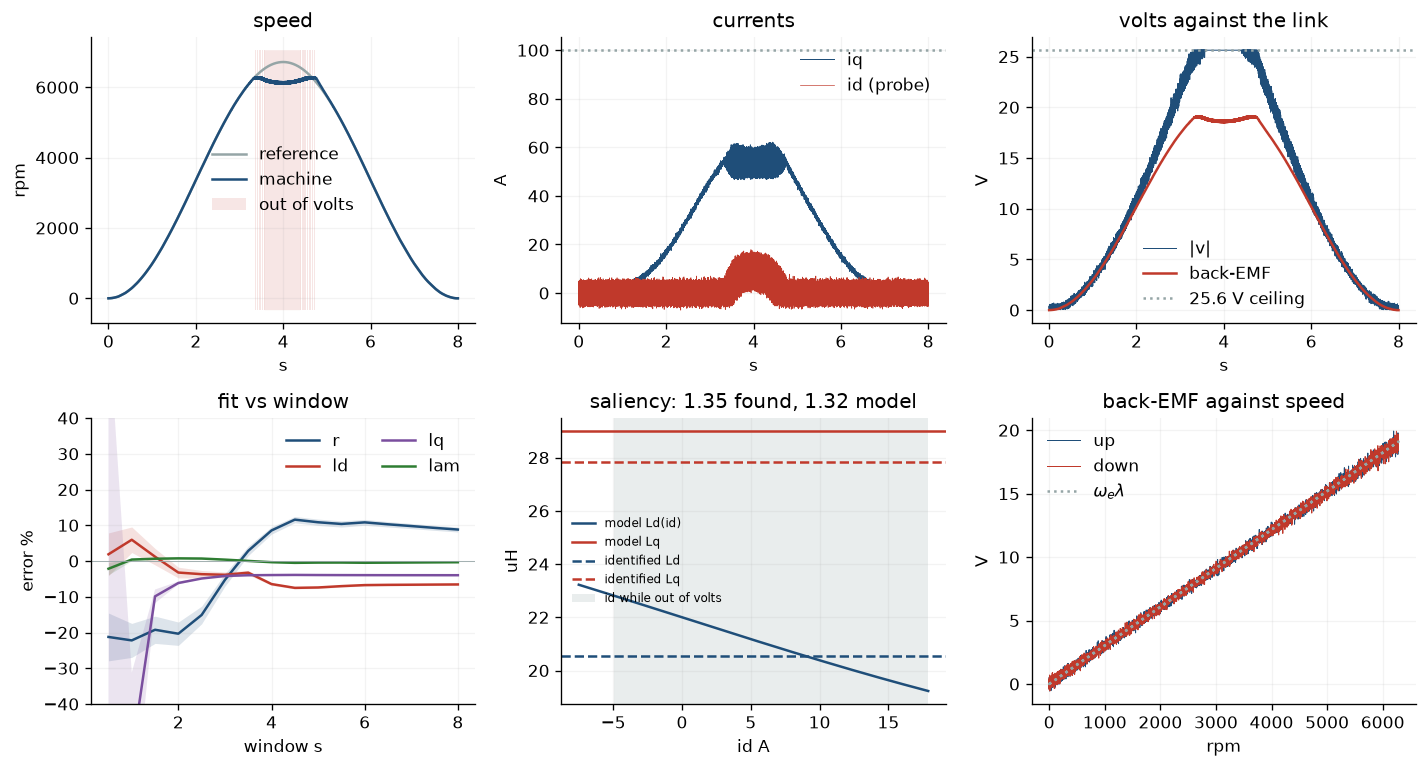

In [3]:
fig, ax = plt.subplots(2, 3, figsize=(12, 6.5))

a = ax[0, 0]
a.plot(t, run['w_ref'] * 60 / (2 * math.pi), color=GREY, label='reference')
a.plot(t, rpm, color=BLUE, label='machine')
lo, hi = a.get_ylim()
a.fill_between(t, lo, hi, where=sat, color=RED, alpha=0.12, lw=0,
               label='out of volts')
a.set(title='speed', xlabel='s', ylabel='rpm')
a.legend(frameon=False)

a = ax[0, 1]
a.plot(t, run['iq'], color=BLUE, lw=0.6, label='iq')
a.plot(t, run['id'], color=RED, lw=0.4, label='id (probe)')
a.axhline(I_LIMIT, color=GREY, ls=':')
a.set(title='currents', xlabel='s', ylabel='A')
a.legend(frameon=False)

a = ax[0, 2]
vmax = LINK_V / math.sqrt(3.0)
a.plot(t, np.hypot(run['vd'], run['vq']), color=BLUE, lw=0.6, label='|v|')
a.plot(t, run['w_e'] * MOTOR.lam, color=RED, label='back-EMF')
a.axhline(vmax, color=GREY, ls=':', label='%.1f V ceiling' % vmax)
a.set(title='volts against the link', xlabel='s', ylabel='V')
a.legend(frameon=False)

a = ax[1, 0]
names = ('r', 'ld', 'lq', 'lam')
true = {k: getattr(MOTOR, k) for k in names}
windows = np.arange(0.5, 2 * RISE_S + 0.01, 0.5)
err = {k: [] for k in names}
unc = {k: [] for k in names}
for w in windows:
    cut = {k: v[t <= w] for k, v in run.items()}
    try:
        _, g = identify(cut, MOTOR.poles)
    except Exception:
        g = {k: float('nan') for k in names}
        g['uncertainty'] = dict(g)
    for k in names:
        err[k].append(100.0 * (g[k] / true[k] - 1.0))
        unc[k].append(100.0 * g['uncertainty'][k])
for k, color in zip(names, (BLUE, RED, '#7a4e9e', '#2e7d32')):
    e, u = np.asarray(err[k]), np.asarray(unc[k])
    a.plot(windows, e, color=color, label=k)
    a.fill_between(windows, e - u, e + u, color=color, alpha=0.15, lw=0)
a.axhline(0.0, color=GREY, lw=0.5)
a.set(title='fit vs window', xlabel='window s', ylabel='error %',
      ylim=(-40, 40))
a.legend(frameon=False, ncol=2)

a = ax[1, 1]
ii = np.linspace(min(-1.5 * PROBE_A, run['id'].min()),
                 max(1.5 * PROBE_A, run['id'].max()), 200)
a.plot(ii, 1e6 * MOTOR.ld * (1 - MOTOR.sat * np.tanh(ii / MOTOR.i_sat)),
       color=BLUE, label='model Ld(id)')
a.axhline(1e6 * MOTOR.lq, color=RED, label='model Lq')
a.axhline(1e6 * got['ld'], color=BLUE, ls='--', label='identified Ld')
a.axhline(1e6 * got['lq'], color=RED, ls='--', label='identified Lq')
a.axvspan(run['id'][sat].min(), run['id'][sat].max(), color=GREY,
          alpha=0.2, lw=0, label='id while out of volts')
a.set(title='saliency: %.2f found, %.2f model'
      % (got['lq'] / got['ld'], MOTOR.saliency),
      xlabel='id A', ylabel='uH')
a.legend(frameon=False, fontsize=7, loc='center left')

a = ax[1, 2]
up = t < RISE_S
eq = run['vq'] - got['r'] * run['iq'] - run['w_e'] * got['ld'] * run['id']
a.plot(rpm[up], eq[up], color=BLUE, lw=0.6, label='up')
a.plot(rpm[~up], eq[~up], color=RED, lw=0.6, label='down')
a.plot(rpm, run['w_e'] * MOTOR.lam, color=GREY, ls=':',
       label='$\\omega_e \\lambda$')
a.set(title='back-EMF against speed', xlabel='rpm', ylabel='V')
a.legend(frameon=False)

fig.tight_layout()

## What came back out

The probe rides at 200 Hz through a 2.5 kS/s record, so the inductances
carry the centred-difference bias of that ratio, and Ld additionally bends
with the probe through the saturation the model was given -- the fit's own
uncertainty is honest about the first and blind to the second. Nothing
here is a measurement: the day this notebook meets the board,
`coaxial.sysid.from_frame` takes the records and the same table comes out
with `measured=True`.

In [4]:
pd.DataFrame({
    'model': [true[k] for k in names],
    'found': [got[k] for k in names],
    'error %': [round(100 * (got[k] / true[k] - 1), 2) for k in names],
    'uncertainty %': [round(100 * got['uncertainty'][k], 2) for k in names],
    'trusted': [got['trusted'][k] for k in names]}, index=names)

,model,found,error %,uncertainty %,trusted
r,0.030000,0.032641,8.80,0.69,True
ld,0.000022,0.000021,-6.55,0.26,True
lq,0.000029,0.000028,-3.97,0.02,True
lam,0.002073,0.002066,-0.34,0.06,True
